In [1]:
# configuration
from pathlib import Path

PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "revenue_final_dataset.csv"

MODEL_DIR = PROJECT_ROOT / "models"

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TARGET = "Total_Amount"

TEST_SIZE = 0.20

RANDOM_STATE = 42

N_SPLITS = 5

In [2]:
# import library
import warnings

warnings.filterwarnings("ignore")

import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    KFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    RobustScaler,
)
from xgboost import XGBRegressor

In [3]:
# load dataset
df = pd.read_csv(DATA_PATH)

print("=" * 80)
print("Dataset Shape")
print("=" * 80)

print(df.shape)

df.head()

Dataset Shape
(17049, 26)


,Age,Gender,City,Product_Category,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,...,Is_Weekend,Month_Sin,Month_Cos,Weekday_Sin,Weekday_Cos,Age_Group,Customer_Type,Pages_Per_Minute,Engagement_Score,Long_Session
0,40,Male,Ankara,Books,29.18,Digital Wallet,Mobile,14,9,1,...,0,5.000000e-01,-0.866025,0.000000,1.000000,36-45,Returning,0.642857,126,0
1,40,Male,Ankara,Home & Garden,506.35,Credit Card,Desktop,14,8,1,...,0,-8.660254e-01,0.500000,0.433884,-0.900969,36-45,Returning,0.571429,112,0
2,40,Male,Ankara,Sports,1664.10,Credit Card,Mobile,15,10,1,...,0,-2.449294e-16,1.000000,0.781831,0.623490,36-45,Returning,0.666667,150,0
3,33,Male,Istanbul,Food,275.45,Digital Wallet,Desktop,16,13,1,...,0,5.000000e-01,-0.866025,0.433884,-0.900969,26-35,Returning,0.812500,208,1
4,33,Male,Istanbul,Beauty,534.45,Credit Card,Mobile,14,7,1,...,0,1.224647e-16,-1.000000,-0.433884,-0.900969,26-35,Returning,0.500000,98,0


In [4]:
# data preparation
X = df.drop(columns=TARGET)

y = df[TARGET]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numerical_features = X.select_dtypes(include=np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

cat_feature_index = [X.columns.get_loc(col) for col in categorical_features]

In [5]:
# preprocessor
def build_preprocessor():
    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "scaler",
                RobustScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent"),
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numerical_features,
            ),
            (
                "cat",
                categorical_pipeline,
                categorical_features,
            ),
        ]
    )

In [6]:
# model registry
def build_models():
    preprocessor = build_preprocessor()

    sklearn_models = {
        "HistGradientBoosting": Pipeline(
            [
                (
                    "prep",
                    preprocessor,
                ),
                (
                    "model",
                    HistGradientBoostingRegressor(
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "XGBoost": Pipeline(
            [
                (
                    "prep",
                    preprocessor,
                ),
                (
                    "model",
                    XGBRegressor(
                        random_state=RANDOM_STATE,
                        objective="reg:squarederror",
                        n_estimators=500,
                        learning_rate=0.05,
                        max_depth=6,
                        subsample=0.8,
                        colsample_bytree=0.8,
                    ),
                ),
            ]
        ),
    }

    native_models = {
        "CatBoost": CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            random_seed=RANDOM_STATE,
            loss_function="RMSE",
            verbose=False,
        )
    }

    return sklearn_models, native_models

In [7]:
# metric helper


def calculate_metrics(y_true, y_pred):
    """
    Calculate regression metrics.
    """

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
    }

In [8]:
# train sklearn model


def train_sklearn_model(name, pipeline):
    start = time.perf_counter()

    pipeline.fit(X_train, y_train)

    train_time = time.perf_counter() - start

    prediction = pipeline.predict(X_test)

    metrics = calculate_metrics(
        y_test,
        prediction,
    )

    cv = cross_validate(
        estimator=pipeline,
        X=X,
        y=y,
        cv=KFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=RANDOM_STATE,
        ),
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
        },
        n_jobs=-1,
    )

    return {
        "Model": name,
        **metrics,
        "CV_R2": cv["test_r2"].mean(),
        "CV_MAE": -cv["test_mae"].mean(),
        "CV_RMSE": -cv["test_rmse"].mean(),
        "Training_Time": train_time,
        "Prediction": prediction,
        "Estimator": pipeline,
    }

In [9]:
# train catboost


def train_catboost_model(name, model):
    start = time.perf_counter()

    model.fit(
        X_train,
        y_train,
        cat_features=cat_feature_index,
    )

    train_time = time.perf_counter() - start

    prediction = model.predict(X_test)

    metrics = calculate_metrics(
        y_test,
        prediction,
    )

    return {
        "Model": name,
        **metrics,
        "CV_R2": np.nan,
        "CV_MAE": np.nan,
        "CV_RMSE": np.nan,
        "Training_Time": train_time,
        "Prediction": prediction,
        "Estimator": model,
    }

In [11]:
# train all models

sklearn_models, native_models = build_models()

results = []

for name, model in sklearn_models.items():
    print(f"Training {name}...")

    results.append(
        train_sklearn_model(
            name=name,
            pipeline=model,
        )
    )

for name, model in native_models.items():
    print(f"Training {name}...")

    results.append(
        train_catboost_model(
            name=name,
            model=model,
        )
    )

Training HistGradientBoosting...
Training XGBoost...
Training CatBoost...


In [12]:
# summary
summary = pd.DataFrame(
    [
        {
            "Model": r["Model"],
            "MAE": r["MAE"],
            "RMSE": r["RMSE"],
            "R2": r["R2"],
            "CV_R2": r["CV_R2"],
            "Training_Time": r["Training_Time"],
        }
        for r in results
    ]
)

summary = summary.sort_values("R2", ascending=False).reset_index(drop=True)

summary

,Model,MAE,RMSE,R2,CV_R2,Training_Time
0,CatBoost,877.920642,1945.950002,0.387136,NaN,22.971266
1,HistGradientBoosting,891.777500,1980.925997,0.364907,0.378146,0.324854
2,XGBoost,932.657814,2018.156233,0.340811,0.339326,1.337686


In [13]:
# best model
best_result = max(
    results,
    key=lambda x: x["R2"],
)

print("=" * 80)
print("Best Model")
print("=" * 80)

print(best_result["Model"])

print()

print(f"R²   : {best_result['R2']:.4f}")
print(f"RMSE : {best_result['RMSE']:.4f}")
print(f"MAE  : {best_result['MAE']:.4f}")

Best Model
CatBoost

R²   : 0.3871
RMSE : 1945.9500
MAE  : 877.9206


In [14]:
# prediction time

for result in results:
    model = result["Estimator"]

    start = time.perf_counter()

    _ = model.predict(X_test)

    prediction_time = time.perf_counter() - start

    result["Prediction_Time"] = prediction_time

In [15]:
# model size

import os
import tempfile

for result in results:
    model = result["Estimator"]

    with tempfile.NamedTemporaryFile(
        suffix=".pkl",
        delete=False,
    ) as tmp:
        joblib.dump(
            model,
            tmp.name,
        )

        size_mb = os.path.getsize(tmp.name) / (1024 * 1024)

    os.remove(tmp.name)

    result["Model_Size_MB"] = size_mb

In [16]:
# final evaluation table
evaluation = pd.DataFrame(
    [
        {
            "Model": r["Model"],
            "MAE": round(r["MAE"], 4),
            "RMSE": round(r["RMSE"], 4),
            "R2": round(r["R2"], 4),
            "CV_R2": (round(r["CV_R2"], 4) if not pd.isna(r["CV_R2"]) else np.nan),
            "Train Time (s)": round(
                r["Training_Time"],
                3,
            ),
            "Predict Time (s)": round(
                r["Prediction_Time"],
                5,
            ),
            "Model Size (MB)": round(
                r["Model_Size_MB"],
                2,
            ),
        }
        for r in results
    ]
)

evaluation = evaluation.sort_values(
    "R2",
    ascending=False,
).reset_index(drop=True)

evaluation

,Model,MAE,RMSE,R2,CV_R2,Train Time (s),Predict Time (s),Model Size (MB)
0,CatBoost,877.9206,1945.9500,0.3871,NaN,22.971,0.01856,0.70
1,HistGradientBoosting,891.7775,1980.9260,0.3649,0.3781,0.325,0.02660,0.13
2,XGBoost,932.6578,2018.1562,0.3408,0.3393,1.338,0.04318,2.19


In [17]:
# best model
best_model = evaluation.iloc[0]

print("=" * 80)
print("BEST MODEL")
print("=" * 80)

print(best_model)

BEST MODEL
Model               CatBoost
MAE                 877.9206
RMSE                 1945.95
R2                    0.3871
CV_R2                    NaN
Train Time (s)        22.971
Predict Time (s)     0.01856
Model Size (MB)          0.7
Name: 0, dtype: object


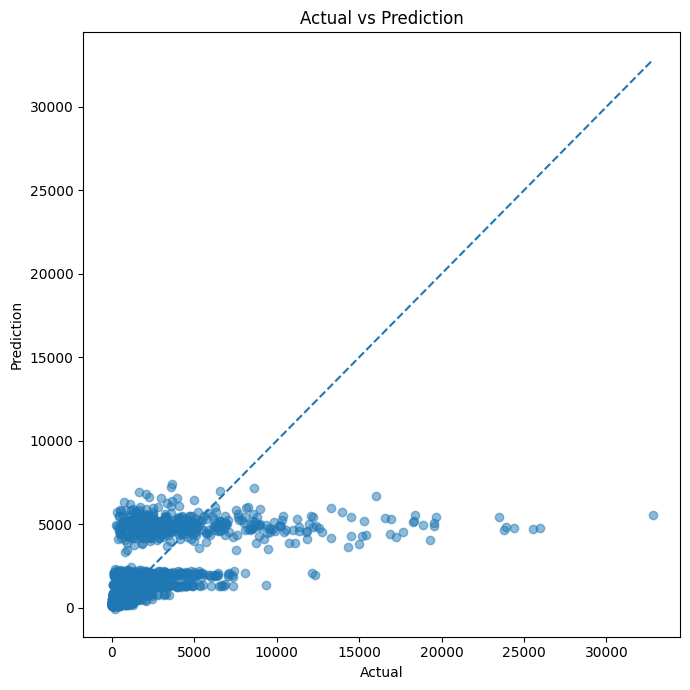

In [18]:
# prediction vs actual
best_prediction = best_result["Prediction"]

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    best_prediction,
    alpha=0.5,
)

minimum = min(
    y_test.min(),
    best_prediction.min(),
)

maximum = max(
    y_test.max(),
    best_prediction.max(),
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
)

plt.xlabel("Actual")

plt.ylabel("Prediction")

plt.title("Actual vs Prediction")

plt.tight_layout()

plt.show()

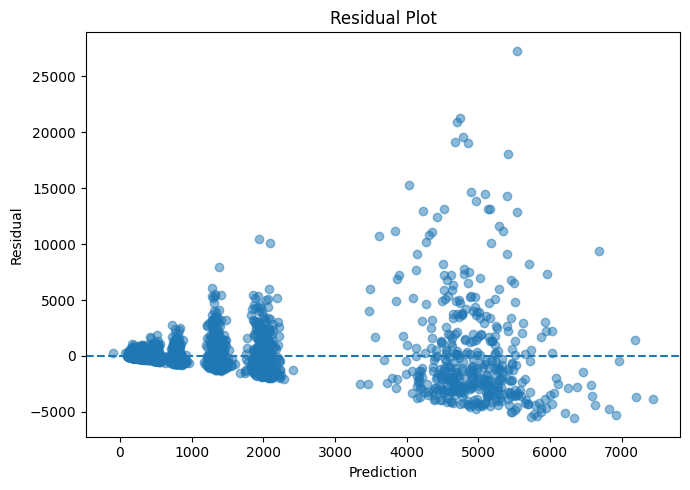

In [19]:
# residual plot
residual = y_test - best_prediction

plt.figure(figsize=(7, 5))

plt.scatter(
    best_prediction,
    residual,
    alpha=0.5,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Prediction")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.tight_layout()

plt.show()

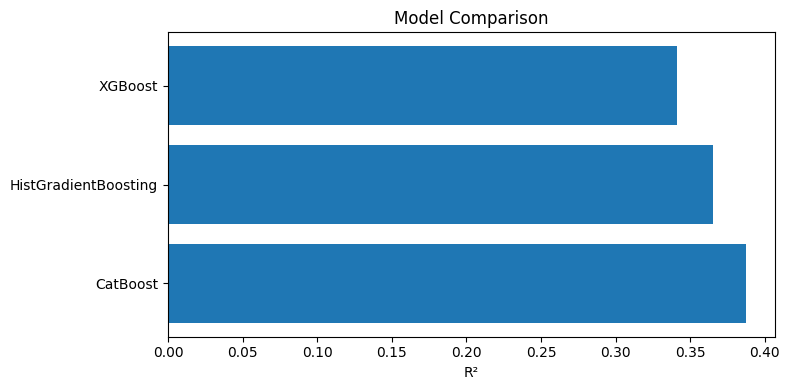

In [20]:
# r2 comparison
plt.figure(figsize=(8, 4))

plt.barh(
    evaluation["Model"],
    evaluation["R2"],
)

plt.xlabel("R²")

plt.title("Model Comparison")

plt.tight_layout()

plt.show()

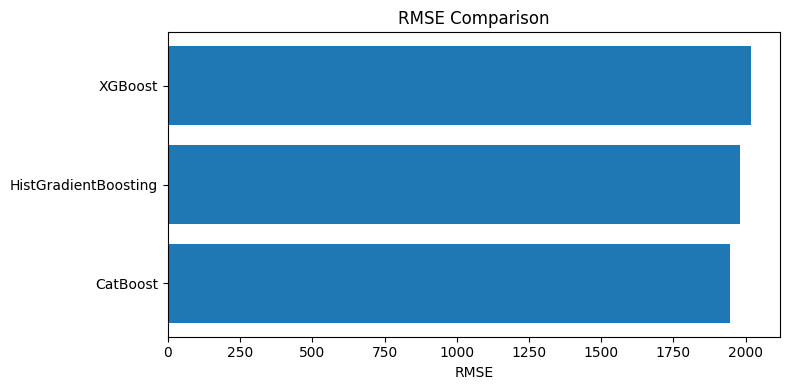

In [21]:
# rmse comparison
plt.figure(figsize=(8, 4))

plt.barh(
    evaluation["Model"],
    evaluation["RMSE"],
)

plt.xlabel("RMSE")

plt.title("RMSE Comparison")

plt.tight_layout()

plt.show()

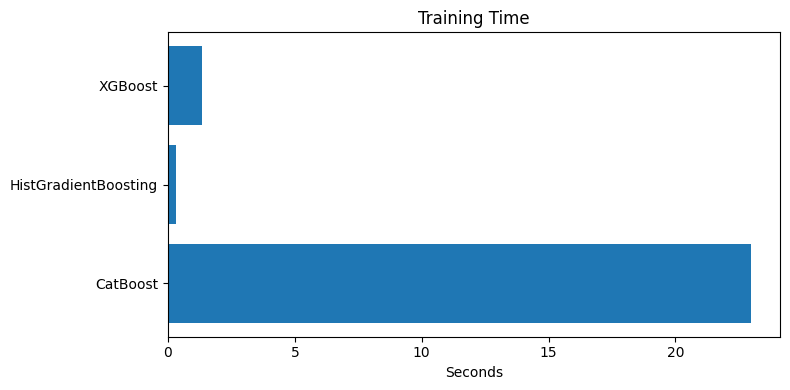

In [22]:
# training time
plt.figure(figsize=(8, 4))

plt.barh(
    evaluation["Model"],
    evaluation["Train Time (s)"],
)

plt.xlabel("Seconds")

plt.title("Training Time")

plt.tight_layout()

plt.show()

In [23]:
# valuation summary
print("=" * 80)
print("Evaluation Summary")
print("=" * 80)

print(evaluation)

Evaluation Summary
                  Model       MAE       RMSE      R2   CV_R2  Train Time (s)  \
0              CatBoost  877.9206  1945.9500  0.3871     NaN          22.971   
1  HistGradientBoosting  891.7775  1980.9260  0.3649  0.3781           0.325   
2               XGBoost  932.6578  2018.1562  0.3408  0.3393           1.338   

   Predict Time (s)  Model Size (MB)  
0           0.01856             0.70  
1           0.02660             0.13  
2           0.04318             2.19  
